**----------IMPORTING LIBRARIES AND DATASET----------**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [ ]:
df=pd.read_csv("/content/diabetes.csv")



**----------BASIC DATA EXPLORATION----------**

In [ ]:
# Shape of dataset
df.shape

(768, 9)

In [ ]:
# Display first five rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Display last five rows
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Disply types of fields
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
# Summary statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Check for missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# Identify duplicate rows based on all columns
df.duplicated().sum()

np.int64(0)

In [ ]:

df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
df["Outcome"].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6,4))
# sns.countplot(x="Outcome", data=df, palette="Set2")
# plt.title("Class Balance in Outcome")
# plt.xlabel("Diabetes Outcome (0 = No, 1 = Yes)")
# plt.ylabel("Count")
# plt.show()

In [ ]:
# class_distribution = df["Outcome"].value_counts(normalize=True) * 100
# print("Class distribution (in percentage):")
# print(class_distribution)

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Convert back to DataFrame for inspection
X_res = pd.DataFrame(X_res, columns=X.columns)
y_res = pd.Series(y_res, name="Outcome")

# Show the new class distribution
print("Original dataset distribution:")
print(y.value_counts())

print("\nResampled dataset distribution:")
print(y_res.value_counts())

print("\nProportion after balancing:")
print(y_res.value_counts(normalize=True))

Original dataset distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Resampled dataset distribution:
Outcome
1    500
0    500
Name: count, dtype: int64

Proportion after balancing:
Outcome
1    0.5
0    0.5
Name: proportion, dtype: float64


**-----------OUTLIER DETECTION------------**

In [ ]:
import pandas as pd

# Copy the data to avoid modifying original
X_res_capped = X_res.copy()

# Columns to check for outliers
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Apply capping to outliers based on IQR
for column in cols_to_check:
    Q1 = X_res_capped[column].quantile(0.25)
    Q3 = X_res_capped[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers_lower = X_res_capped[column] < lower_bound
    outliers_upper = X_res_capped[column] > upper_bound
    total_outliers = outliers_lower.sum() + outliers_upper.sum()

    # Cap values at the bounds
    X_res_capped.loc[outliers_lower, column] = lower_bound
    X_res_capped.loc[outliers_upper, column] = upper_bound

    print(f"Capped {total_outliers} outliers in column '{column}'")

print("\nAll outliers capped, dataset shape preserved:")
print(X_res_capped.shape)

Capped 5 outliers in column 'Glucose'
Capped 67 outliers in column 'BloodPressure'
Capped 1 outliers in column 'SkinThickness'
Capped 32 outliers in column 'Insulin'
Capped 23 outliers in column 'BMI'

All outliers capped, dataset shape preserved:
(1000, 8)


/tmp/ipython-input-3928644547.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-49.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_res_capped.loc[outliers_lower, column] = lower_bound


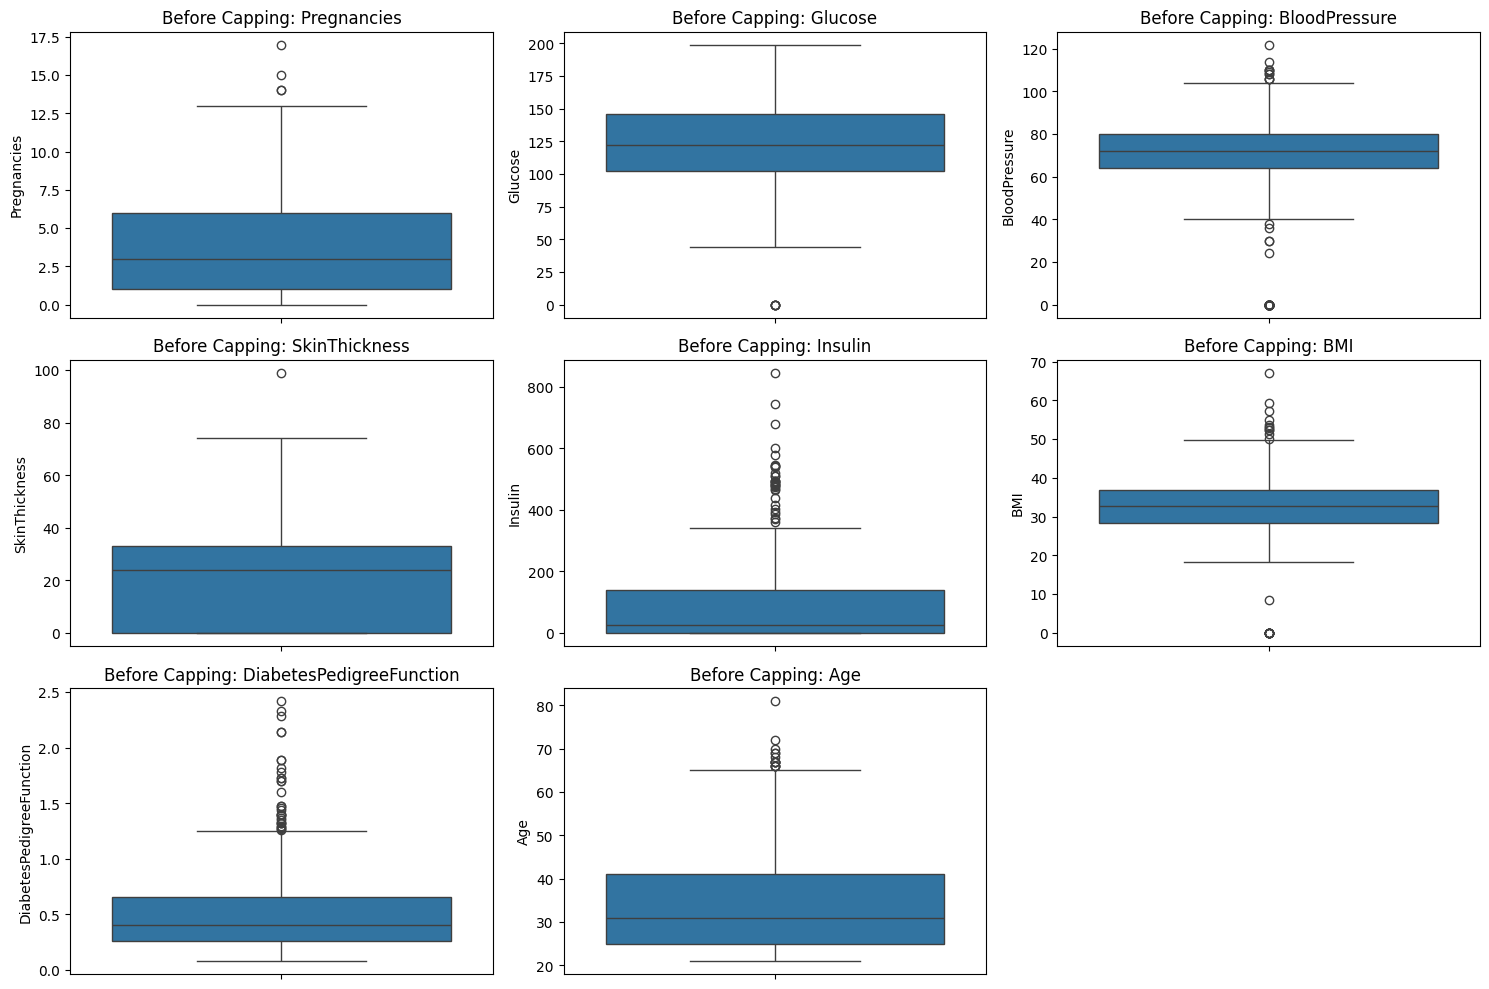

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(X_res.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=X_res[column])
    plt.title(f"Before Capping: {column}")
plt.tight_layout()
plt.show()

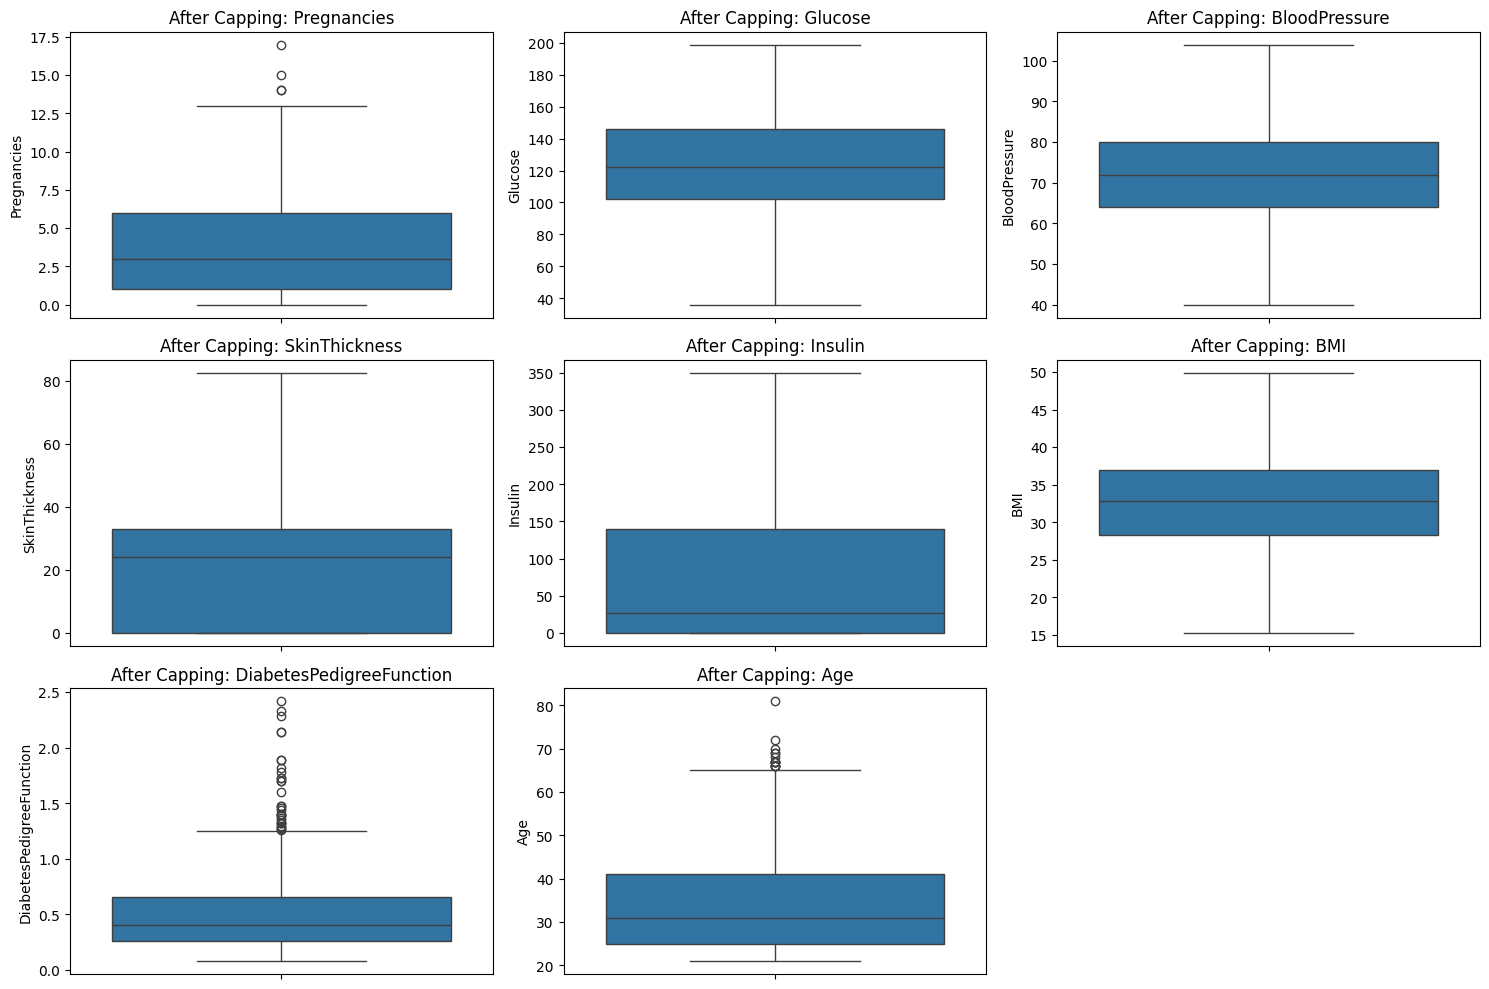

In [ ]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(X_res_capped.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=X_res_capped[column])
    plt.title(f"After Capping: {column}")
plt.tight_layout()
plt.show()

In [ ]:
# # Plot boxplots for each numerical feature
# plt.figure(figsize=(15, 10))
# for i, column in enumerate(df.columns[:-1], 1):  # Exclude target column
#     plt.subplot(3, 3, i)
#     sns.boxplot(y=df[column])
#     plt.title(f"Boxplot of {column}")

# plt.tight_layout()
# plt.show()

In [ ]:
# # List of columns to check for outliers
# cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# # Copy the data to preserve original
# X_res_clean = X_res.copy()
# y_res_clean = y_res.copy()

# # Apply IQR method to remove outliers
# for column in cols_to_check:
#     Q1 = X_res_clean[column].quantile(0.25)
#     Q3 = X_res_clean[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     # Filter rows within the valid range
#     before_rows = X_res_clean.shape[0]
#     condition = (X_res_clean[column] >= lower_bound) & (X_res_clean[column] <= upper_bound)
#     X_res_clean = X_res_clean[condition]
#     y_res_clean = y_res_clean.loc[X_res_clean.index]
#     after_rows = X_res_clean.shape[0]

#     print(f"Removed {before_rows - after_rows} outliers from '{column}'")

# print("\nFinal dataset shape after removing outliers:")
# print(X_res_clean.shape)

In [ ]:
# # Function to remove outliers using IQR for a single column
# def remove_outliers_iqr(df, column):
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     # Filter the dataframe
#     filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
#     print(f"Removed {len(df) - len(filtered_df)} outliers from {column}")
#     return filtered_df

# # Example: Removing outliers from all relevant numerical columns
# for column in ['Pregnancies','Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
#     df = remove_outliers_iqr(df, column)

# print("Shape after removing outliers:", df.shape)

**---------- DATA VISUALIZATION ----------**

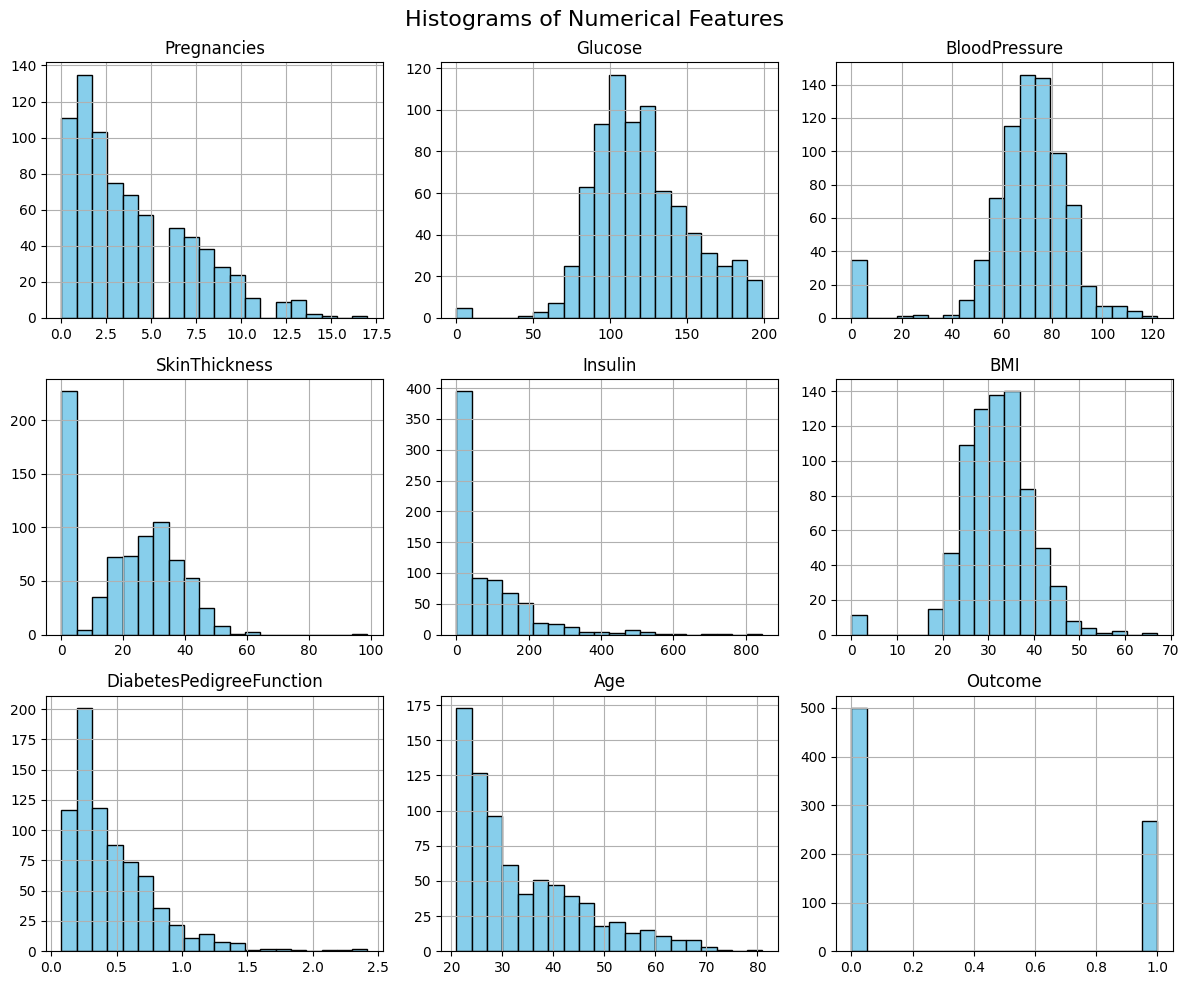

In [ ]:


# Plot histograms for all numerical features
df.hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')

# Set the title for the overall figure
plt.suptitle("Histograms of Numerical Features", fontsize=16)

# Adjust layout so titles and labels don’t overlap
plt.tight_layout()

# Show the plot
plt.show()

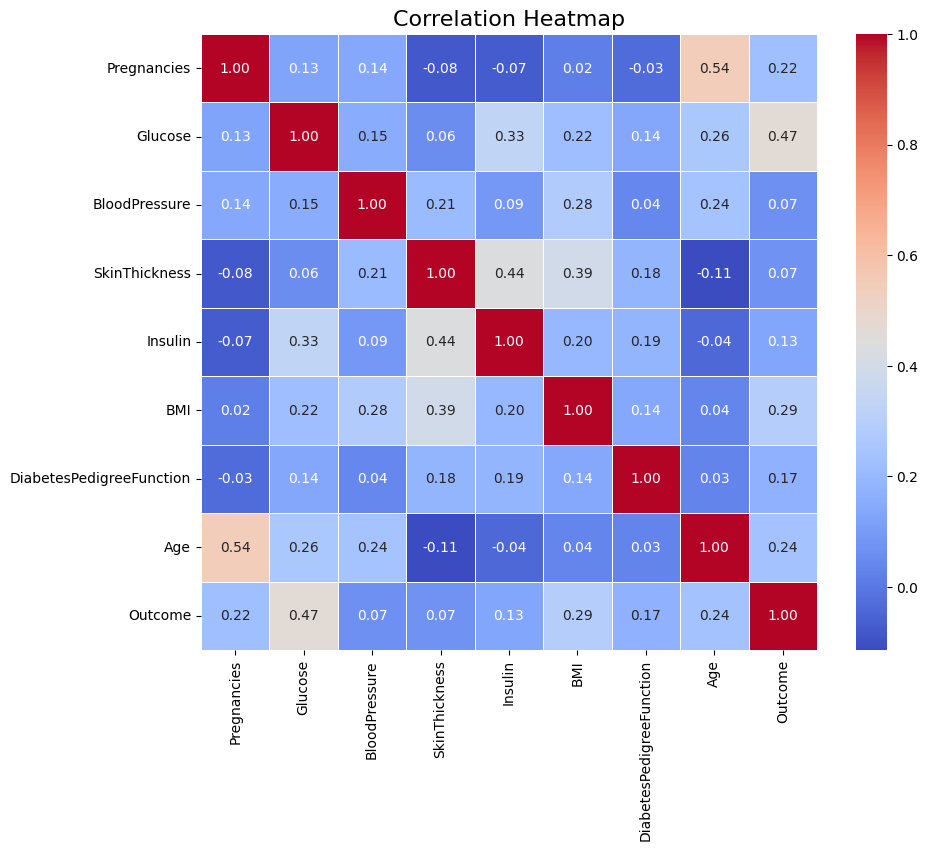

In [ ]:


# Compute the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

# Title for the heatmap
plt.title("Correlation Heatmap", fontsize=16)

# Display the plot
plt.show()

/tmp/ipython-input-3906828703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette="Set2")


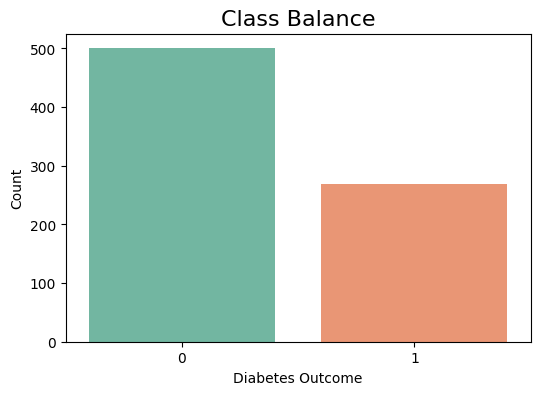

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class distribution (in percentage):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [ ]:


# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Outcome", data=df, palette="Set2")
plt.title("Class Balance", fontsize=16)
plt.xlabel("Diabetes Outcome")
plt.ylabel("Count")
plt.show()

# Print class distribution
print("Class distribution:")
print(df["Outcome"].value_counts())

# Print percentage distribution
print("\nClass distribution (in percentage):")
print(df["Outcome"].value_counts(normalize=True) * 100)

**-----------HANDLING MISSING VALUES--------**

In [ ]:
# Count zeros in columns where 0 is not a valid value
cols_with_zero= ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero:
    zero_count = (df[col] == 0).sum()
    print(f"{col} has {zero_count} invalid zero values")

Glucose has 5 invalid zero values
BloodPressure has 35 invalid zero values
SkinThickness has 227 invalid zero values
Insulin has 374 invalid zero values
BMI has 11 invalid zero values


In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [ ]:
# Re check the values
cols_with_zero= ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero:
    zero_count = (df[col] == 0).sum()
    print(f"{col} has {zero_count} invalid zero values")

Glucose has 0 invalid zero values
BloodPressure has 0 invalid zero values
SkinThickness has 0 invalid zero values
Insulin has 0 invalid zero values
BMI has 0 invalid zero values


**--------Normalize/standardize features---------**

In [ ]:


# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for convenience
X = pd.DataFrame(X_scaled, columns=X.columns)

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.831114,-0.608201,0.167240,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,0.180566,-0.608201,-0.851551,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.469981,-0.608201,-1.331838,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.469981,-0.006185,-0.633239,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.831114,0.695378,1.549885,5.484909,-0.020496


** ---------Encode labels--------**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Check if target is not numeric
if df["Outcome"].dtype == 'object':
    le = LabelEncoder()
    df["Outcome"] = le.fit_transform(df["Outcome"])
    print("Labels encoded.")
else:
    print("Labels are already numeric.")

# Confirm by showing unique values
print("Unique target values:", df["Outcome"].unique())

Labels are already numeric.
Unique target values: [1 0]


In [ ]:
# from sklearn.model_selection import train_test_split

# # Features and target
# X = df.drop("Outcome", axis=1)
# y = df["Outcome"]

# # Split into training and test sets (80% train, 20% test)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Display the size of each set
# print("Training set size:", X_train.shape)
# print("Test set size:", X_test.shape)

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier

# # Create model instances
# log_reg = LogisticRegression(max_iter=1000, random_state=42)
# tree_clf = DecisionTreeClassifier(random_state=42)
# forest_clf = RandomForestClassifier(random_state=42)

# # Train the models
# log_reg.fit(X_train, y_train)
# tree_clf.fit(X_train, y_train)
# forest_clf.fit(X_train, y_train)

# # Evaluate on training and test sets
# print("Logistic Regression")
# print(" - Train accuracy:", log_reg.score(X_train, y_train))
# print(" - Test accuracy:", log_reg.score(X_test, y_test))

# print("\nDecision Tree")
# print(" - Train accuracy:", tree_clf.score(X_train, y_train))
# print(" - Test accuracy:", tree_clf.score(X_test, y_test))

# print("\nRandom Forest")
# print(" - Train accuracy:", forest_clf.score(X_train, y_train))
# print(" - Test accuracy:", forest_clf.score(X_test, y_test))

In [ ]:
# Save the cleaned dataset to a CSV file
X_res_capped['Outcome'] = y_res  # Add target column back before saving
X_res_capped.to_csv('cleaned_diabetes_dataset.csv', index=False)